# Distribución por Categoría

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from empiricaldist import Pmf, Cdf


########################## CARGA DESDE ARCHIVO LOCAL ##########################
# Cargar el archivo local
data = pd.read_csv("cln_vista_agrosavia_Municipio_Funza_20260111_cleaned.csv", sep=",", encoding="utf-8")

# Ver las primeras filas
display(data.head())


,Departamento,Municipio,Cultivo,Estado,Topografia,Drenaje,Riego,Fertilizantes aplicados,Secuencial
0,CUNDINAMARCA,FUNZA,Guisantes,Por Establecer,Plano,Buen drenaje,Goteo,urea,166.0
1,CUNDINAMARCA,FUNZA,Lechuga,Por Establecer,Plano,Buen drenaje,Aspersión,15-15-15,248.0
2,CUNDINAMARCA,FUNZA,Zanahoria,Por Establecer,Plano,Buen drenaje,Aspersión,15-15-15,249.0
3,CUNDINAMARCA,FUNZA,Maíz,Por Establecer,Plano,Buen drenaje,Aspersión,15-15-15,306.0
4,CUNDINAMARCA,FUNZA,Lechuga,Establecido,Plano,Buen drenaje,Aspersión,"compostaje+quimico edafico+(dap,kcl+fertilizac...",388.0


En variables categóricas como son la mayoría en este conjunto de datos, la PMF es la herramienta fundamental para describir la distribución de probabilidades. A partir de ella pueden construirse distribuciones acumuladas discretas, pero no funciones de densidad continua (PDF) o funciones de distribución acumulada continua (CDF).

In [ ]:
# Calcular la PMF para la columna "Cultivo" para validar su distribución y probabilidades // P(Cultivo)

# Se desea conocer la distribución de cultivos en el conjunto de datos.
# Para ello, se calcula la PMF de la columna "Cultivo".

pmf_cultivo = (
    data["Cultivo"]
    .value_counts(normalize=True)
    .sort_values(ascending=False)
)
# pmf_cultivo.sum() # 1
# display(pmf_cultivo)

pmf_cultivo_df = pmf_cultivo.reset_index()
pmf_cultivo_df.columns = ["Cultivo", "Probabilidad"]
display(pmf_cultivo_df) 


,Cultivo,Probabilidad
0,Uchuva,0.159091
1,Lechuga,0.125000
2,Ajo,0.079545
3,Pasto Kikuyo,0.079545
4,No Indica,0.079545
5,Pastos,0.068182
6,Gulupa,0.045455
7,Hortalizas Varias,0.045455
8,Calas,0.034091
9,Tomate,0.034091


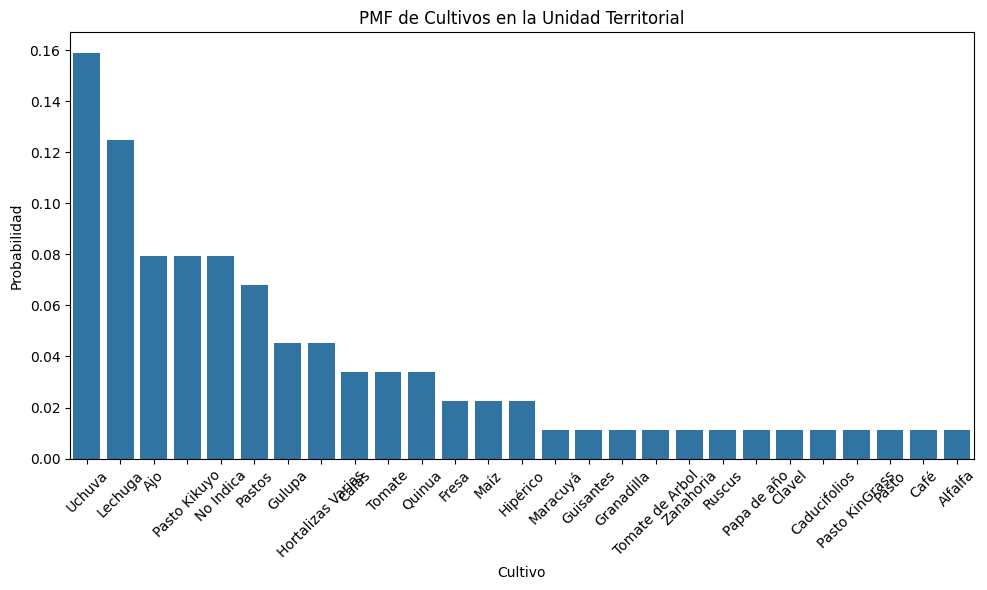

In [ ]:
# Graficar la PMF para Cultivo
plt.figure(figsize=(10, 6))
sns.barplot(x="Cultivo", y="Probabilidad", data=pmf_cultivo_df)
plt.title("PMF de Cultivos en la Unidad Territorial")
plt.xlabel("Cultivo")
plt.ylabel("Probabilidad")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Graficar la PMF acumulada del cultivo permite visualizar la probabilidad acumulada asociada a la frecuencia relativa de cada cultivo en el dataset.
# Se observa que la uchuva presenta la mayor probabilidad de ocurrencia; sin embargo, para este análisis se consideran los 12 cultivos con mayor frecuencia,  con el fin de enfocarse en los patrones más representativos del conjunto de datos.

Esta PMF **no representa la probabilidad real de siembra en la región**, sino la **probabilidad empírica dentro del dataset observado**.

In [ ]:
# Calcular la PMF para la columna "Riego" para validar su distribución y probabilidades // P(Riego)

pmf_riego = (
    data["Riego"]
    .value_counts(normalize=True)
    .sort_values(ascending=False)
)
pmf_riego_df = pmf_riego.reset_index()
pmf_riego_df.columns = ["Riego", "Probabilidad"]
display(pmf_riego_df)

,Riego,Probabilidad
0,No indica,0.420455
1,Aspersión,0.375000
2,Goteo,0.068182
3,No Tiene,0.068182
4,Cañon,0.045455
5,Manguera,0.022727


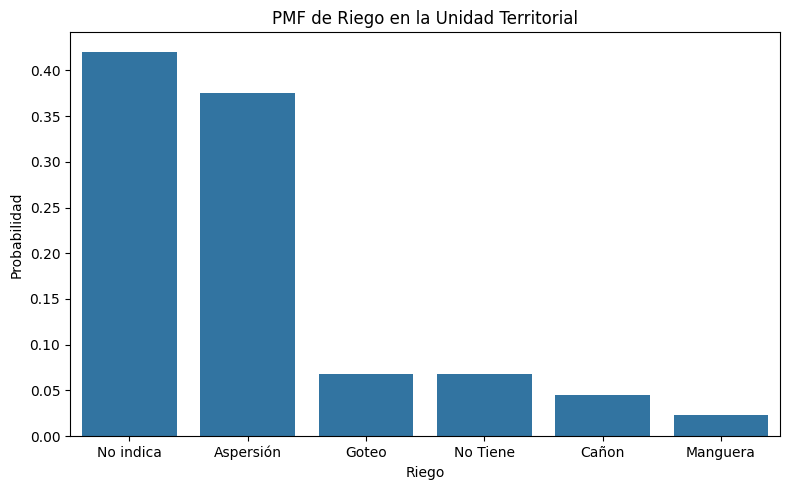

In [ ]:
# Graficar la PMF para Riego
plt.figure(figsize=(8, 5))
sns.barplot(x="Riego", y="Probabilidad", data=pmf_riego_df)
plt.title("PMF de Riego en la Unidad Territorial")
plt.xlabel("Riego")
plt.ylabel("Probabilidad")
plt.tight_layout()
plt.show() 


# La distribución de probabilidad del sistema de riego muestra lamentablemetne una alta concentración de registros en la categoría "No indica".
# Pero entre los sistemas informados, el riego por aspersión es claramente el más frecuente, mientras que tecnologías como el riego por goteo presentan una participación significativamente menor en el conjunto de datos.


In [ ]:
# Calcular la PMF para la columna "Drenaje" para validar su distribución y probabilidades // P(Drenaje)

pmf_drenaje = (
    data["Drenaje"]
    .value_counts(normalize=True)
    .sort_values(ascending=False)
)
pmf_drenaje_df = pmf_drenaje.reset_index()
pmf_drenaje_df.columns = ["Drenaje", "Probabilidad"]
display(pmf_drenaje_df)

,Drenaje,Probabilidad
0,Buen drenaje,0.727273
1,No indica,0.181818
2,Regular drenaje,0.079545
3,Mal drenaje,0.011364


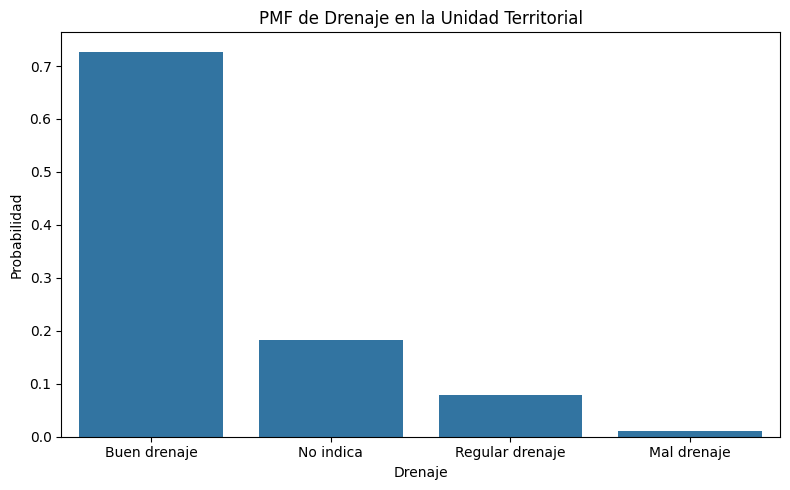

In [ ]:
# Graficar la PMF para Drenaje 
plt.figure(figsize=(8, 5))
sns.barplot(x="Drenaje", y="Probabilidad", data=pmf_drenaje_df)
plt.title("PMF de Drenaje en la Unidad Territorial")
plt.xlabel("Drenaje")
plt.ylabel("Probabilidad")
plt.tight_layout()
plt.show()


# La distribución de probabilidad del tipo de drenaje muestra un claro predominio de la categoría "Buen drenaje", lo que sugiere que la mayoría de los predios registrados presentan condiciones favorables para el manejo del exceso de agua.
# No obstante, la presencia de registros sin información ("No indica") introduce cierta incertidumbre, especialmente al analizar cultivos sensibles al encharcamiento (por ejemplo en el caso del ajo y la lechuga que presenta la mayor cantidad de registros sin información).

In [ ]:
# Calcular la PMF para la columna "Topografia" para validar su distribución y probabilidades // P(Topografia)

pmf_topografia = (
    data["Topografia"]
    .value_counts(normalize=True)
    .sort_values(ascending=False)
)
pmf_topografia_df = pmf_topografia.reset_index()
pmf_topografia_df.columns = ["Topografia", "Probabilidad"]
display(pmf_topografia_df)

,Topografia,Probabilidad
0,Plano,0.647727
1,Ondulado,0.159091
2,No indica,0.090909
3,Moderadamente ondulado,0.034091
4,Pendiente moderada,0.034091
5,Pendiente,0.022727
6,Pendiente fuerte,0.011364


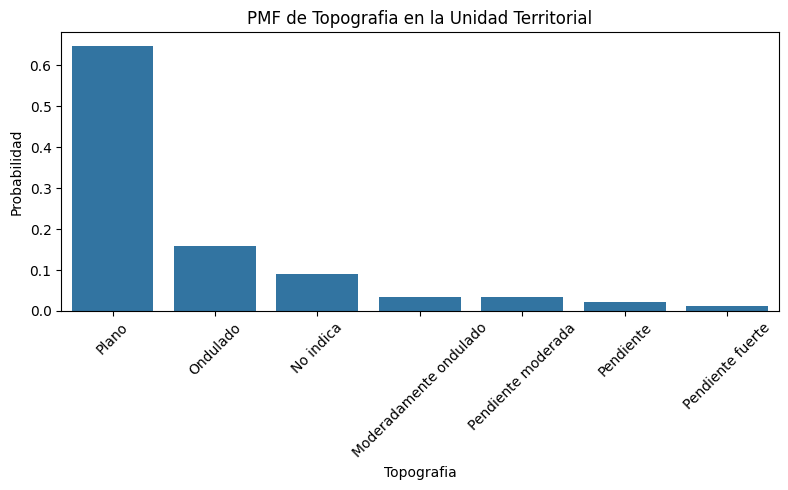

In [ ]:
# Graficar la PMF para Topografia
plt.figure(figsize=(8, 5))
sns.barplot(x="Topografia", y="Probabilidad", data=pmf_topografia_df)
plt.title("PMF de Topografia en la Unidad Territorial")
plt.xlabel("Topografia")
plt.ylabel("Probabilidad")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# La distribución de la topografía indica claro predominio de terrenos planos, lo cual sugiere condiciones favorables para la mecanización, el riego presurizado y un manejo agrícola relativamente homogéneo de la unidad territorial.
# Las categorías onduladas y con pendiente representan una proporción menor, pero son importantes para evaluar a futuro la viabilidad de sistemas como el riego por goteo, el manejo de escorrentía, manjeo de la erocion, manejo de lixiviados y manejo agronomico o hasta posible cambio de uso.
# La presencia de registros sin información ("No indica") limita la capacidad de realizar inferencias más precisas en algunos cultivos.
